# Data Loading

In [1]:
import pandas as pd

df = pd.read_csv("Final_Data.csv")

df


,Age,Blood Pressure,Glucose Level,Cholesterol,Exercise Level,Sleep Hours,Family history of disease,Diet quality,Heart rate,Waist circumference,Target Disease Risk
0,56,99,76,294,2,8.9,0,1,69,108.6,0
1,69,91,82,234,1,7.9,1,0,108,64.1,0
2,46,155,189,286,0,9.0,1,1,72,65.7,2
3,32,149,135,293,0,9.7,1,1,61,80.5,2
4,60,177,73,272,1,5.6,1,1,67,67.1,2
...,...,...,...,...,...,...,...,...,...,...,...
2000,20,163,188,202,2,4.3,0,1,101,110.7,2
2001,54,140,127,229,0,6.1,1,1,104,77.2,2
2002,60,156,132,165,1,4.5,0,1,107,74.5,1
2003,57,165,169,253,2,6.4,0,1,108,100.9,2


# Separate features and target

In [2]:
X = df.drop("Target Disease Risk", axis=1)
y = df["Target Disease Risk"]


# Train-test split

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Train Decision Tree model

In [4]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5   # prevents overfitting (recommended)
)

dt_model.fit(X_train, y_train)

print("Decision Tree trained successfully")


Decision Tree trained successfully


# Make predictions

In [5]:
y_pred_dt = dt_model.predict(X_test)


# Model Evaluation

In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, average="weighted"))
print("Recall:", recall_score(y_test, y_pred_dt, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred_dt, average="weighted"))



Accuracy: 0.743142144638404
Precision: 0.7224730716582483
Recall: 0.743142144638404
F1 Score: 0.7307224771174281


# ROC AUC and Log Loss

In [7]:
from sklearn.metrics import roc_auc_score, log_loss

y_prob_dt = dt_model.predict_proba(X_test)

print("ROC AUC Score:", roc_auc_score(y_test, y_prob_dt, multi_class="ovr"))
print("Log Loss:", log_loss(y_test, y_prob_dt))


ROC AUC Score: 0.8531621020965927
Log Loss: 1.2069472574785254


# Confusion Matrix

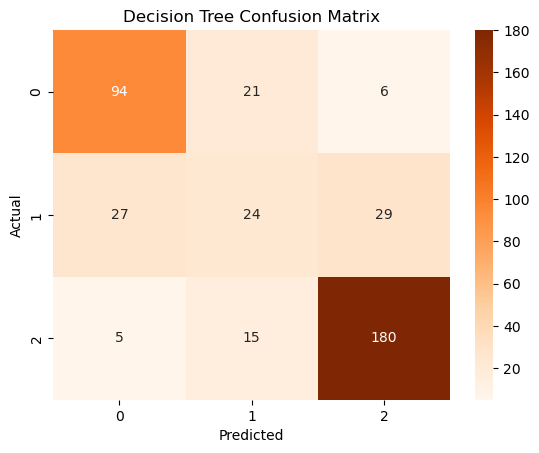

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()


# ROC curve Plot

<Figure size 800x600 with 0 Axes>

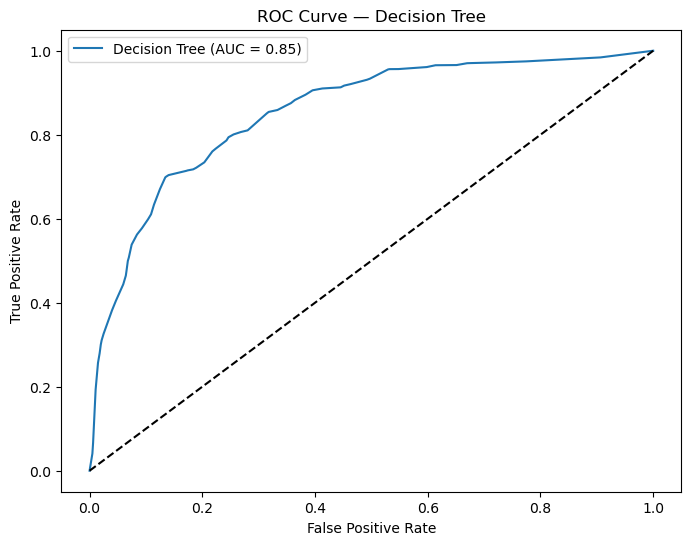

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)


y_prob_dt = dt_model.predict_proba(X_test)


plt.figure(figsize=(8,6))

fpr = dict()
tpr = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_dt[:, i])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes))]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(len(classes)):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= len(classes)
roc_auc = auc(all_fpr, mean_tpr)

plt.figure(figsize=(8,6))
plt.plot(all_fpr, mean_tpr, label=f"Decision Tree (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Decision Tree")
plt.legend()
plt.show()



# Saving Model

In [11]:
import pickle

with open("decision_tree_model.pkl", "wb") as f:
    pickle.dump(dt_model, f)

print('Model Saved')

Model Saved
